In [12]:
import sys
sys.path.append("..") 

%matplotlib inline
import pandas as pd
import torch
from torch import nn
from src.data_loader import get_dataloaders
%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Config Param

In [13]:
CSV_PATH = "../Preprocessed_Data/all_tickers_processed.csv"  # Đường dẫn file dữ liệu
TARGET_COLUMN = "Future_Return_10D"  # Cột mục tiêu cần dự đoán (Future_Return_1D hoặc Next_Close)

LOOK_BACK = 30     # Số ngày lịch sử nhìn lại (độ dài chuỗi thời gian)
BATCH_SIZE = 32    # Kích thước Batch khi huấn luyện
SPLIT_CODE = "702010"  # Tỉ lệ chia Train/Val/Test (70% Train, 20% Val, 10% Test)
SCALE_TARGET = True    # Có chuẩn hóa nhãn mục tiêu y hay không


### 1. Data Loader

In [14]:
# Lấy các PyTorch DataLoader và Scaler (bao gồm cả ticker_to_idx)
train_loader, val_loader, test_loader, x_scaler, y_scaler, ticker_to_idx = get_dataloaders(
    csv_path=CSV_PATH,
    look_back=LOOK_BACK,
    batch_size=BATCH_SIZE,
    split_code=SPLIT_CODE,
    target_column=TARGET_COLUMN,
    scale_target=SCALE_TARGET
)

# Lấy thử 1 batch đầu tiên từ train_loader để kiểm tra kích thước
first_batch_x, first_batch_ticker, first_batch_y = next(iter(train_loader))

print("--- KIỂM TRA KÍCH THƯỚC DỮ LIỆU ---")
print("Kích thước X (batch, look_back, features):", first_batch_x.shape)
print("Kích thước chỉ mục Ticker (batch,)       :", first_batch_ticker.shape)
print("Kích thước nhãn mục tiêu y (batch, 1)    :", first_batch_y.shape)

--- KIỂM TRA KÍCH THƯỚC DỮ LIỆU ---
Kích thước X (batch, look_back, features): torch.Size([32, 30, 21])
Kích thước chỉ mục Ticker (batch,)       : torch.Size([32])
Kích thước nhãn mục tiêu y (batch, 1)    : torch.Size([32, 1])


### 2. CNN-LSTM + Entity Embedding


In [15]:
class CNNLSTMModel(nn.Module):
    def __init__(self, num_features, seq_len, num_tickers=27, embedding_dim=8):
        super(CNNLSTMModel, self).__init__()
        # Ticker Entity Embedding
        self.ticker_embedding = nn.Embedding(num_embeddings=num_tickers, embedding_dim=embedding_dim)
        
        self.conv = nn.Conv1d(in_channels=num_features + embedding_dim, out_channels=64, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout1 = nn.Dropout(0.2)
        
        self.lstm = nn.LSTM(input_size=64, hidden_size=100, num_layers=1, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc = nn.Linear(100, 1)
        
    def forward(self, x_numeric, x_ticker):
        # x_numeric shape: (batch, seq_len, num_features)
        # x_ticker shape: (batch,)
        
        # 1. Get Ticker Embed
        ticker_emb = self.ticker_embedding(x_ticker)
        
        # 3. Concat with the numeric features
        seq_len = x_numeric.size(1)
        ticker_emb = ticker_emb.unsqueeze(1).repeat(1, seq_len, 1)
        
        x = torch.cat([x_numeric, ticker_emb], dim=-1)
        
        # 3. Transpose for Conv1d (required shape: (batch, channels, seq_len) )
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)
        
        # 4. Transpose forLSTM (required shape: (batch, seq_len, channels) )
        x = x.transpose(1, 2)
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # 5. Get target at last 
        out = lstm_out[:, -1, :]
        out = self.dropout2(out)
        out = self.fc(out)
        return out

### 3. Train & Evaluate (Training Loop with Early Stopping)

In [16]:
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, patience=10):
    criterion = nn.HuberLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    best_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    history = {'train_loss': [], 'val_loss': []}
    
    print("Bắt đầu huấn luyện mô hình CNN-LSTM (với Entity Embedding)...")
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for batch_x, batch_ticker, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_x, batch_ticker)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_x.size(0)
            
        train_loss /= len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_ticker, batch_y in val_loader:
                pred = model(batch_x, batch_ticker)
                loss = criterion(pred, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                
        val_loss /= len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{epochs:02d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
            
        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping kích hoạt tại Epoch {epoch} do Val Loss không cải thiện trong {patience} epochs.")
                break
                
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    return history

### 4. Khởi tạo và Khởi chạy Huấn luyện

In [ ]:
# Khởi tạo mô hình dựa trên chiều đặc trưng đầu tiên của batch dữ liệu
num_features = first_batch_x.shape[2]
seq_len = first_batch_x.shape[1]
num_tickers = len(ticker_to_idx)

model = CNNLSTMModel(num_features=num_features, seq_len=seq_len, num_tickers=num_tickers, embedding_dim=8)

history = train_model(model, train_loader, val_loader, epochs=50, lr=0.001, patience=15)

Bắt đầu huấn luyện mô hình CNN-LSTM (với Entity Embedding)...
Epoch 01/100 | Train Loss: 0.373873 | Val Loss: 0.238723
Epoch 10/100 | Train Loss: 0.175918 | Val Loss: 0.330222
Early stopping kích hoạt tại Epoch 16 do Val Loss không cải thiện trong 15 epochs.


### 5. Đánh giá kết quả trên tập Test (và so sánh với thang đo gốc)

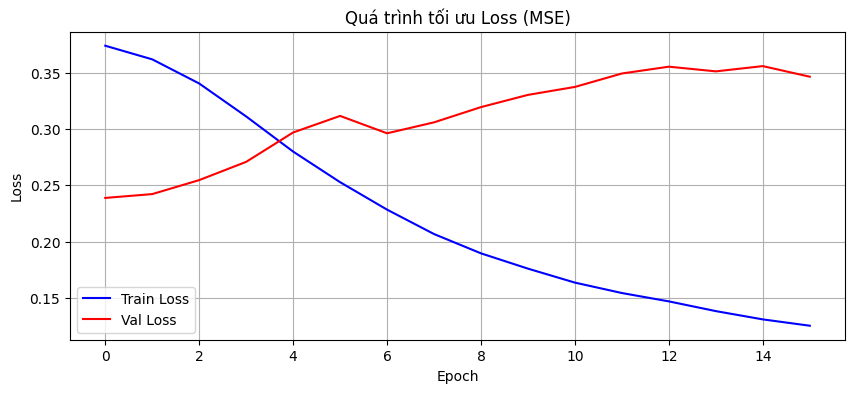

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (THANG ĐO GỐC)
Mean Absolute Error (MAE): 0.080557
Root Mean Squared Error (RMSE): 0.111926
R-squared (R2 Score)        : -0.433419


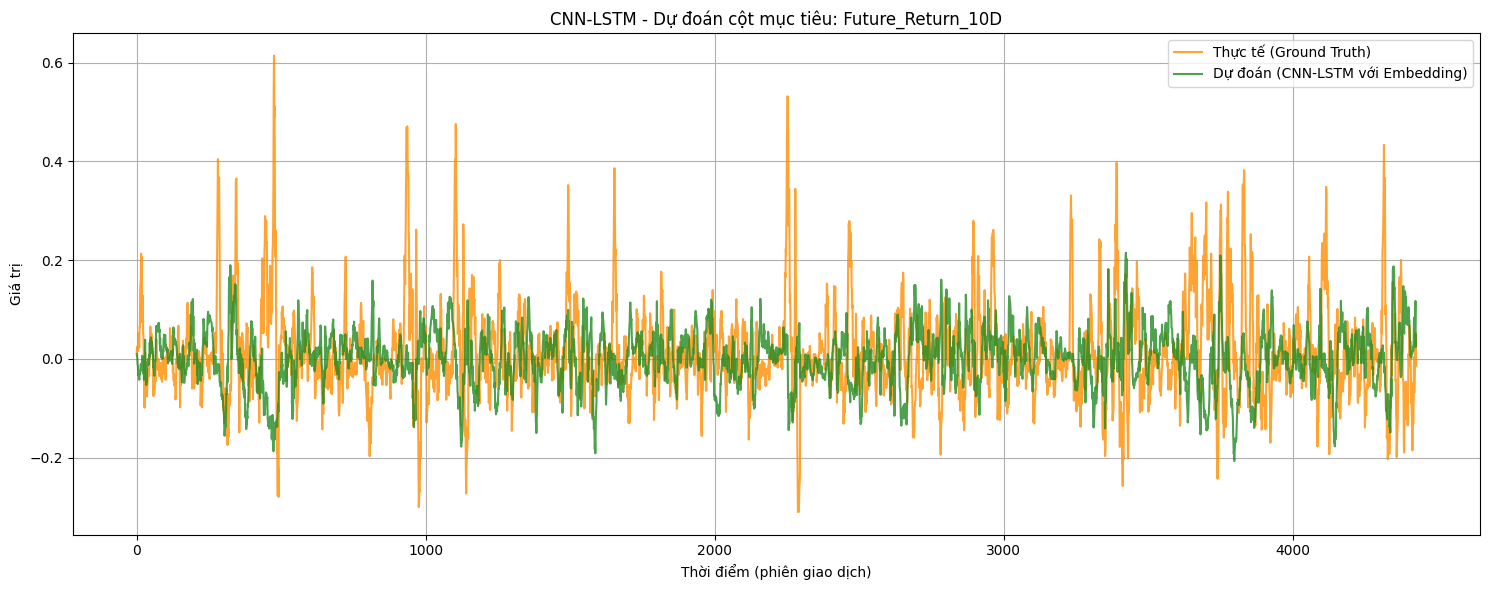

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Vẽ đồ thị Loss
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='red')
plt.title('Quá trình tối ưu Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2. Dự đoán trên tập Test
model.eval()
test_preds = []
test_trues = []

with torch.no_grad():
    for batch_x, batch_ticker, batch_y in test_loader:
        preds = model(batch_x, batch_ticker)
        test_preds.append(preds.numpy())
        test_trues.append(batch_y.numpy())

test_preds = np.vstack(test_preds)
test_trues = np.vstack(test_trues)

# Đưa ngược về thang đo gốc (inverse scale) nếu có chuẩn hóa
if y_scaler is not None:
    y_pred_original = y_scaler.inverse_transform(test_preds)
    y_true_original = y_scaler.inverse_transform(test_trues)
else:
    y_pred_original = test_preds
    y_true_original = test_trues

mae = mean_absolute_error(y_true_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
r2 = r2_score(y_true_original, y_pred_original)

print("=" * 50)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (THANG ĐO GỐC)")
print("=" * 50)
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R-squared (R2 Score)        : {r2:.6f}")
print("=" * 50)

# 4. Vẽ đồ thị so sánh thực tế và dự đoán
plt.figure(figsize=(15, 6))
plt.plot(y_true_original, label='Thực tế (Ground Truth)', color='darkorange', alpha=0.8)
plt.plot(y_pred_original, label='Dự đoán (CNN-LSTM với Embedding)', color='forestgreen', alpha=0.8)
plt.title(f'CNN-LSTM - Dự đoán cột mục tiêu: {TARGET_COLUMN}')
plt.xlabel('Thời điểm (phiên giao dịch)')
plt.ylabel('Giá trị')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()